# Análise Geográfica e de Categorias  ·  *análise central do challenge*
### Olist · Tech Challenge Fase 1 (POSTECH DTAT)

**Problema a resolver:** a Olist é, na prática, um e-commerce do **Sudeste** (65% da receita). O crescimento
futuro depende de destravar as outras regiões — mas elas se comportam de formas muito diferentes. Este
notebook é a **espinha dorsal da apresentação** e responde a duas perguntas de negócio:

> **Q1 — Por que Nordeste e Centro-Oeste compram menos que o Sul?**
> **Q2 — O que pode ser melhorado para cumprir as promessas de data de entrega?**

**Recorte das regiões críticas (decisão de escopo):**
- 🟦 **Norte** — problema **geográfico não-resolvível** pela empresa (rios, falta de estradas). Reconhecido, não é o foco da solução.
- 🟥 **Nordeste** e 🟨 **Centro-Oeste** — **o foco**: há demanda, falta destravar.
- 🟩 **Sul** — **benchmark positivo**: a região "fora do Sudeste" que deu certo.

> **Escopo:** apenas pedidos **entregues** (`delivered`) — ver o adendo logo abaixo. **Convenção de métricas:**
> _ticket médio_ = **mercadoria** (`price`, sem frete); _receita_ = `price+frete` (GMV); _frete %_ = **mediana de
> `frete/preço` por pedido**.

> Os estudos de apoio (crescimento, top performers, profundidade/RFM) estão nos notebooks 01, 03 e 04 — aqui
> eles entram só como evidência a serviço da tese geográfica.

## 0. Setup, carga e escopo

Bloco reprodutível idêntico em todos os notebooks: carrega os 9 datasets do Olist, define o **escopo canônico — apenas pedidos entregues (`delivered`)** — e enriquece a tabela de itens com categoria traduzida e UF de cliente/seller. Os pedidos **não entregues** são tratados no adendo e excluídos da análise.

> **Convenção de métricas:** _ticket médio_ = valor da **mercadoria** (`price`, sem frete); _receita/faturamento_ = `price + frete` (GMV); _frete %_ = mediana do `frete/price` **por pedido**.



In [1]:
# === Setup: imports e tema visual ===
from pathlib import Path
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Localiza a raiz do projeto (onde existe a pasta data/)
ROOT = Path.cwd()
for cand in [ROOT, *ROOT.parents]:
    if (cand / "data" / "olist_orders_dataset.csv").exists():
        ROOT = cand; break
DATA_DIR = ROOT / "data"
FIG_DIR  = ROOT / "figs";    FIG_DIR.mkdir(exist_ok=True, parents=True)
OUT_DIR  = ROOT / "outputs"; OUT_DIR.mkdir(exist_ok=True, parents=True)

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    "figure.figsize": (12, 6), "figure.dpi": 100, "savefig.dpi": 150,
    "savefig.bbox": "tight", "axes.titleweight": "bold",
    "axes.spines.top": False, "axes.spines.right": False,
})
# Paleta Darwin / Olist
ROSA, PRETO, TEAL, AMARELO, AZUL, CINZA = "#de0078","#1f1f1f","#00a3a1","#ffb800","#5b6bf5","#8c8c8c"
PALETTE = [ROSA, TEAL, AMARELO, AZUL, CINZA, PRETO]

def brl(x, _=None):
    return f"R$ {x:,.0f}".replace(",", ".")
print("Projeto:", ROOT)

Projeto: C:\Users\vitor\tc_olist


In [2]:
# === Carga dos 9 datasets do Olist ===
def load(name):
    df = pd.read_csv(DATA_DIR / name)
    return df

orders    = load("olist_orders_dataset.csv")
items     = load("olist_order_items_dataset.csv")
payments  = load("olist_order_payments_dataset.csv")
reviews   = load("olist_order_reviews_dataset.csv")
products  = load("olist_products_dataset.csv")
customers = load("olist_customers_dataset.csv")
sellers   = load("olist_sellers_dataset.csv")
cat_trans = load("product_category_name_translation.csv")

ts_cols = ["order_purchase_timestamp","order_approved_at","order_delivered_carrier_date",
           "order_delivered_customer_date","order_estimated_delivery_date"]
for c in ts_cols:
    orders[c] = pd.to_datetime(orders[c], errors="coerce")

print(f"orders={orders.shape} | items={items.shape} | payments={payments.shape} | reviews={reviews.shape}")
print(f"Janela de compra: {orders['order_purchase_timestamp'].min().date()} -> {orders['order_purchase_timestamp'].max().date()}")

orders=(99441, 8) | items=(112650, 7) | payments=(103886, 5) | reviews=(99224, 7)
Janela de compra: 2016-09-04 -> 2018-10-17


In [3]:
# === Escopo canonico: APENAS pedidos ENTREGUES (delivered) ===
# Decisao de escopo: usamos somente pedidos efetivamente entregues. Os casos nao
# entregues (shipped/invoiced/processing/canceled/unavailable/...) sao mostrados
# separadamente no ADENDO e excluidos da analise -- so os entregues tem data de
# entrega, frete realizado e review confiaveis.
ESCOPO_STATUS = "delivered"
orders_v = orders[orders["order_status"] == ESCOPO_STATUS].copy()
orders_v["year_month"] = orders_v["order_purchase_timestamp"].dt.to_period("M")

# Convencao do projeto (duas metricas distintas, NAO confundir):
#  - gross_price   = valor da MERCADORIA do pedido (soma dos precos dos itens)  -> base do TICKET MEDIO
#  - order_revenue = gross_price + frete (GMV recebido pela plataforma)         -> base da RECEITA/FATURAMENTO
# Ticket medio considera APENAS o produto (sem frete). Frete entra so como variavel propria.
items_rev = (items.groupby("order_id")
                  .agg(gross_price=("price","sum"),
                       freight=("freight_value","sum"),
                       n_items=("order_item_id","count"))
                  .reset_index())
items_rev["order_revenue"] = items_rev["gross_price"] + items_rev["freight"]

orders_v = orders_v.merge(items_rev, on="order_id", how="left")
orders_v = orders_v.merge(
    customers[["customer_id","customer_unique_id","customer_state","customer_city"]],
    on="customer_id", how="left")
orders_v["lead_time_dias"] = (orders_v["order_delivered_customer_date"]
                              - orders_v["order_purchase_timestamp"]).dt.days
# Frete como % do preco, calculado POR PEDIDO (a mediana disso = frete do pedido tipico)
orders_v["frete_pct_pedido"] = orders_v["freight"] / orders_v["gross_price"].replace(0, np.nan)

# Tabela de itens enriquecida (categoria PT->EN, UF cliente, UF seller)
items_full = (items.merge(products[["product_id","product_category_name"]], on="product_id", how="left")
                   .merge(cat_trans, on="product_category_name", how="left")
                   .merge(orders_v[["order_id","year_month","customer_state","customer_city"]], on="order_id", how="inner")
                   .merge(sellers[["seller_id","seller_state","seller_city"]], on="seller_id", how="left"))
items_full["revenue"] = items_full["price"] + items_full["freight_value"]
items_full["cat"] = (items_full["product_category_name_english"]
                     .fillna("sem_categoria").str.replace("_"," ").str.title())

print(f"Escopo: APENAS pedidos entregues (delivered)")
print(f"Pedidos entregues: {orders_v['order_id'].nunique():,}")
print(f"Clientes unicos:   {orders_v['customer_unique_id'].nunique():,}")
print(f"Receita total (GMV c/ frete): R$ {orders_v['order_revenue'].sum():,.2f}")
print(f"Ticket medio (mercadoria):    R$ {orders_v['gross_price'].mean():,.2f}")
print(f"Frete % do preco (mediana por pedido): {orders_v['frete_pct_pedido'].median():.1%}")

Escopo: APENAS pedidos entregues (delivered)
Pedidos entregues: 96,478
Clientes unicos:   93,358
Receita total (GMV c/ frete): R$ 15,419,773.75
Ticket medio (mercadoria):    R$ 137.04
Frete % do preco (mediana por pedido): 22.4%


In [4]:
REGIAO = {**dict.fromkeys(["AC","AP","AM","PA","RO","RR","TO"],"Norte"),
 **dict.fromkeys(["AL","BA","CE","MA","PB","PE","PI","RN","SE"],"Nordeste"),
 **dict.fromkeys(["DF","GO","MT","MS"],"Centro-Oeste"),
 **dict.fromkeys(["ES","MG","RJ","SP"],"Sudeste"),
 **dict.fromkeys(["PR","RS","SC"],"Sul")}
COR_REG = {"Norte":AZUL,"Nordeste":ROSA,"Centro-Oeste":AMARELO,"Sudeste":CINZA,"Sul":TEAL}
ORDEM = ["Norte","Nordeste","Centro-Oeste","Sudeste","Sul"]
FOCO = ["Nordeste","Centro-Oeste","Sul"]
orders_v["regiao"] = orders_v["customer_state"].map(REGIAO)
items_full["regiao"] = items_full["customer_state"].map(REGIAO)
print("Regiões mapeadas.")

Regiões mapeadas.


## ⚠️ Adendo — escopo da análise: apenas pedidos *entregues*

Antes de qualquer número, o recorte de escopo. A base do Olist tem pedidos em vários estágios do funil. **Toda a
análise daqui em diante usa exclusivamente os pedidos com status `delivered`** (efetivamente entregues), porque
só eles têm **data de entrega, frete realizado e avaliação** confiáveis. Os pedidos **não entregues** são
mostrados abaixo — de forma transparente — e **excluídos** das análises seguintes.

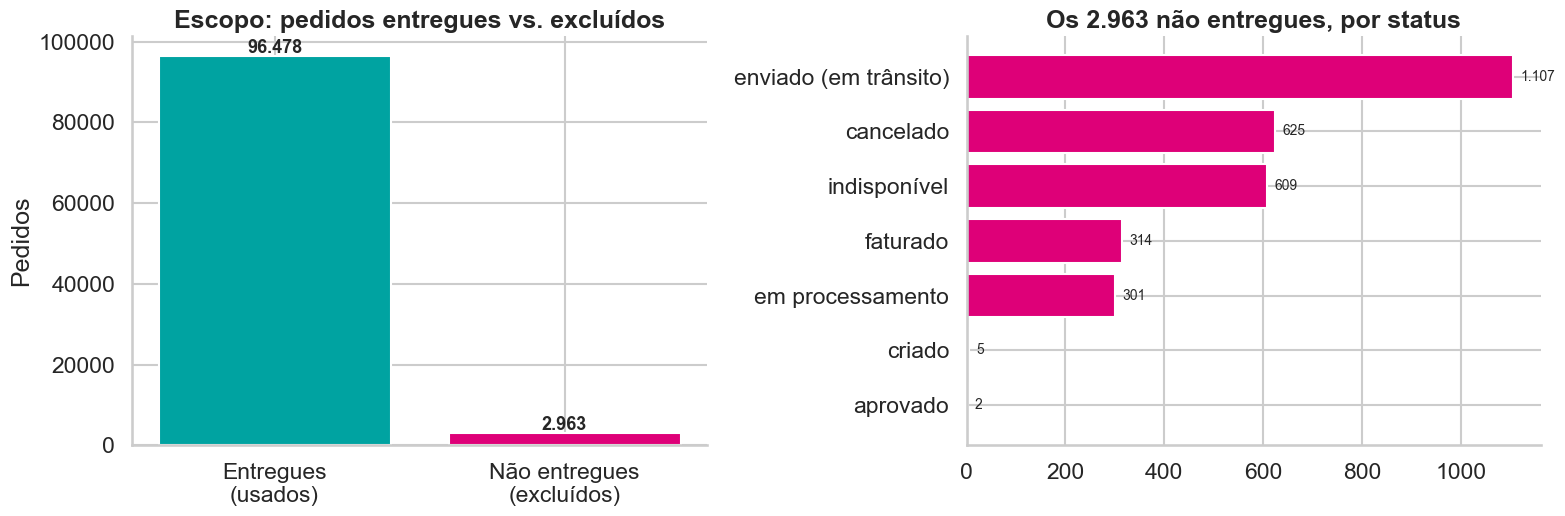

Total na base:   99.441
ENTREGUES (usados): 96.478  (97.0%)
NÃO entregues (excluídos): 2.963  (3.0%)

Detalhe dos excluídos:
order_status
enviado (em trânsito)    1107
cancelado                 625
indisponível              609
faturado                  314
em processamento          301
criado                      5
aprovado                    2


In [5]:
vc = orders["order_status"].value_counts()
entregues = int(vc.get("delivered",0))
nao_entregues = int(len(orders) - entregues)
# detalhamento dos NAO entregues
nd = vc.drop("delivered").sort_values(ascending=False)
rotulo = {"shipped":"enviado (em trânsito)","invoiced":"faturado","processing":"em processamento",
          "approved":"aprovado","created":"criado","canceled":"cancelado","unavailable":"indisponível"}

fig, ax = plt.subplots(1,2, figsize=(16,5.5))
# esq: entregue vs nao entregue
ax[0].bar(["Entregues\n(usados)","Não entregues\n(excluídos)"], [entregues, nao_entregues], color=[TEAL, ROSA])
for i,v in enumerate([entregues, nao_entregues]):
    ax[0].text(i, v+800, f"{v:,}".replace(",","."), ha="center", fontsize=13, weight="bold")
ax[0].set_title("Escopo: pedidos entregues vs. excluídos"); ax[0].set_ylabel("Pedidos")
# dir: detalhamento dos excluidos
labels = [rotulo.get(s,s) for s in nd.index]
ax[1].barh(labels[::-1], nd.values[::-1], color=ROSA)
for i,v in enumerate(nd.values[::-1]):
    ax[1].text(v+15, i, f"{v:,}".replace(",","."), va="center", fontsize=10)
ax[1].set_title(f"Os {nao_entregues:,}".replace(",",".") + " não entregues, por status")
plt.tight_layout(); plt.savefig(FIG_DIR/"geo_adendo_status.png"); plt.show()

print(f"Total na base:   {len(orders):,}".replace(",","."))
print(f"ENTREGUES (usados): {entregues:,}  ({entregues/len(orders):.1%})".replace(",","."))
print(f"NÃO entregues (excluídos): {nao_entregues:,}  ({nao_entregues/len(orders):.1%})".replace(",","."))
print("\nDetalhe dos excluídos:")
print(nd.rename(index=rotulo).to_string())

### Quanto custa e por que falharam

Os não entregues não são pedidos "em andamento" — são **falhas reais**: têm mediana de 9–13 meses de idade,
a data prometida já venceu em ~100% e a nota de review é péssima (1,3–2,0). Quantificando a perda e o motivo:

In [6]:
nd_orders = orders[orders["order_status"]!="delivered"].copy()
nd_it = nd_orders.merge(items, on="order_id", how="left")
perda_prod = nd_it["price"].sum(); perda_frete = nd_it["freight_value"].sum()
nd_rev = nd_orders.merge(reviews[["order_id","review_score"]].drop_duplicates("order_id"), on="order_id", how="left")
nota_por_status = nd_rev.groupby("order_status")["review_score"].mean().round(2)
# postado? (entregue a transportadora)
nd_orders["postado"] = nd_orders["order_delivered_carrier_date"].notna()
# qualidade de dados
neg_post = int((orders["order_delivered_carrier_date"]<orders["order_purchase_timestamp"]).sum())
neg_trans = int((orders["order_delivered_customer_date"]<orders["order_delivered_carrier_date"]).sum())
miss_del = int(orders[orders["order_status"]=="delivered"]["order_delivered_customer_date"].isna().sum())

print(f"PERDA (receita em risco): produto R$ {perda_prod:,.2f} + frete R$ {perda_frete:,.2f}".replace(",","."))
print(f"\nNota média de review por status (todos péssimos = falha real):")
print(nota_por_status.to_string())
print(f"\nshipped postado e nunca entregue (perdido em trânsito): {int((nd_orders['order_status']=='shipped').sum())}")
print(f"Qualidade de dados — postagem negativa: {neg_post} | transporte negativo: {neg_trans} | delivered sem data: {miss_del}")

PERDA (receita em risco): produto R$ 370.145.59 + frete R$ 53.633.90

Nota média de review por status (todos péssimos = falha real):
order_status
approved       2.50
canceled       1.80
created        2.33
invoiced       1.63
processing     1.28
shipped        2.00
unavailable    1.53

shipped postado e nunca entregue (perdido em trânsito): 1107
Qualidade de dados — postagem negativa: 166 | transporte negativo: 23 | delivered sem data: 8


**Os 4 modos de falha** (e o que cada um diz):
- 🚚 **Perdido no transporte — `shipped` (37%):** pago e postado, mas nunca chegou. É o **mesmo elo frágil do Q2**
  (a perna de transporte). O maior grupo, e pior no NE (não-entrega de **3,73%** vs 2,36% no Sul).
- 📦 **Sem estoque — `unavailable` (21%):** pago, produto não existia. **Pior nota (1,5)** — falha de catálogo do seller.
- ⏳ **Travado — `invoiced`/`processing` (21%):** pago e o vendedor **nunca despachou**. Falha de fulfillment.
- ❌ **Cancelado (21%):** 88% antes de postar; 12% já postados (desistência por atraso).

> **Impacto:** ~**R$ 370 mil** de produto + R$ 53,6 mil de frete em **receita em risco** (parte é reembolsada).
> Isso aponta um **segundo problema, operacional**, ao lado do geográfico: integridade de estoque e SLA de fulfillment.
> _(Governança: a base ainda tem 166+23 registros com intervalos de tempo fisicamente impossíveis — tratados/sinalizados.)_

> **Por que excluir e não "salvar" os não entregues:** um pedido `shipped` ou `processing` ainda não gerou frete
> realizado nem avaliação; `canceled`/`unavailable` nunca viraram venda. Manter só os `delivered` garante que
> **todo número se refere a uma transação completa e auditável** — e concilia o Nordeste em **9.044 pedidos**.

## 1. O problema em uma imagem: concentração geográfica

A receita é hiperconcentrada no Sudeste. Antes de entrar em "por quê", o tamanho do problema: quanto cada
região representa, e como o ticket de mercadoria sobe à medida que a distância do Sudeste aumenta.

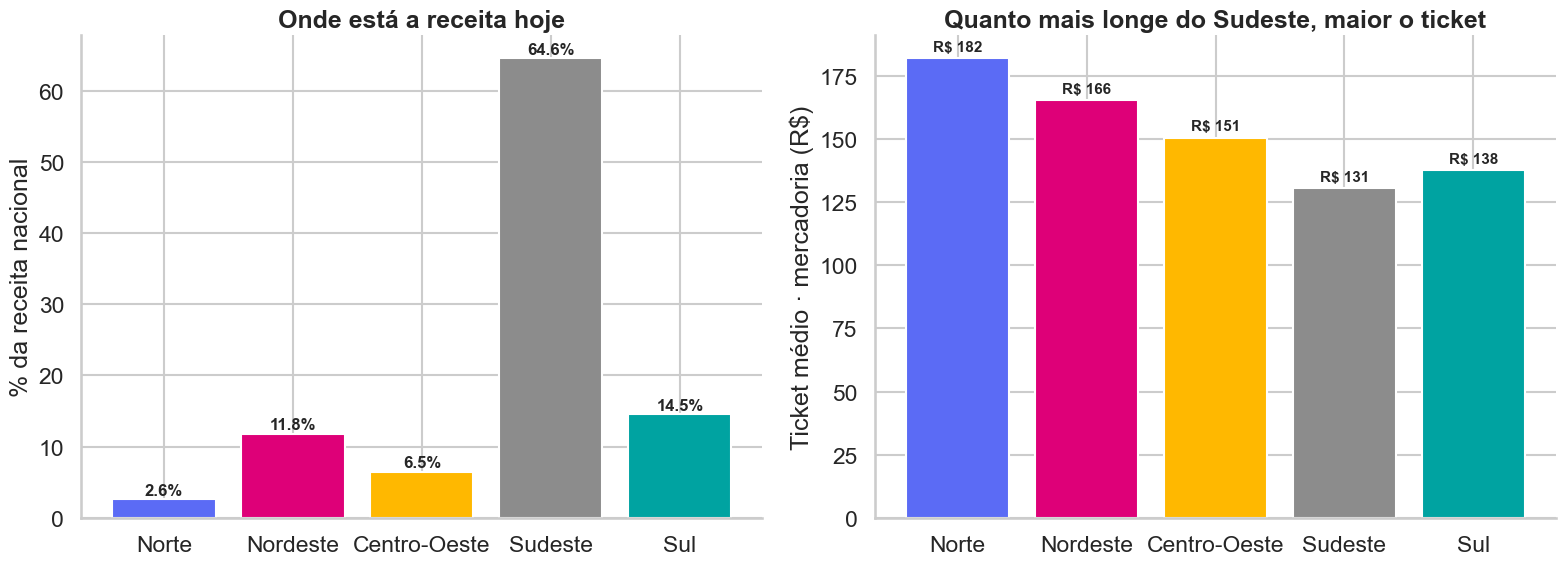

              share_receita  pedidos  ticket_merc  frete_pct
regiao                                                      
Norte                 0.026     1796        182.1       35.7
Nordeste              0.118     9044        165.5       31.5
Centro-Oeste          0.065     5624        150.6       25.2
Sudeste               0.646    66200        130.6       20.6
Sul                   0.145    13814        137.7       25.1


In [7]:
reg = (orders_v.dropna(subset=["order_revenue"]).groupby("regiao")
       .agg(receita=("order_revenue","sum"),
            produto=("gross_price","sum"),
            pedidos=("order_id","nunique"),
            clientes=("customer_unique_id","nunique"),
            frete_pct=("frete_pct_pedido","median")).reindex(ORDEM))
reg["share_receita"] = reg["receita"]/reg["receita"].sum()
reg["ticket_merc"] = reg["produto"]/reg["pedidos"]
reg["frete_pct"] *= 100

fig, ax = plt.subplots(1,2, figsize=(16,6))
ax[0].bar(reg.index, reg["share_receita"]*100, color=[COR_REG[r] for r in reg.index])
ax[0].set_ylabel("% da receita nacional"); ax[0].set_title("Onde está a receita hoje")
for i,v in enumerate(reg["share_receita"]*100):
    ax[0].text(i, v+0.6, f"{v:.1f}%", ha="center", fontsize=12, weight="bold")
ax[1].bar(reg.index, reg["ticket_merc"], color=[COR_REG[r] for r in reg.index])
ax[1].set_ylabel("Ticket médio · mercadoria (R$)"); ax[1].set_title("Quanto mais longe do Sudeste, maior o ticket")
for i,v in enumerate(reg["ticket_merc"]):
    ax[1].text(i, v+3, f"R$ {v:.0f}", ha="center", fontsize=11, weight="bold")
plt.tight_layout(); plt.savefig(FIG_DIR/"geo_00_panorama.png"); plt.show()
print(reg[["share_receita","pedidos","ticket_merc","frete_pct"]].round({"share_receita":3,"ticket_merc":1,"frete_pct":1}).to_string())

### Participação por categoria

O lado "Categorias" do problema: a receita se espalha por uma cauda longa saudável de categorias — nenhuma
domina. Isso importa para a tese geográfica: o sortimento que precisa chegar às regiões não é de 2-3 itens,
é amplo.

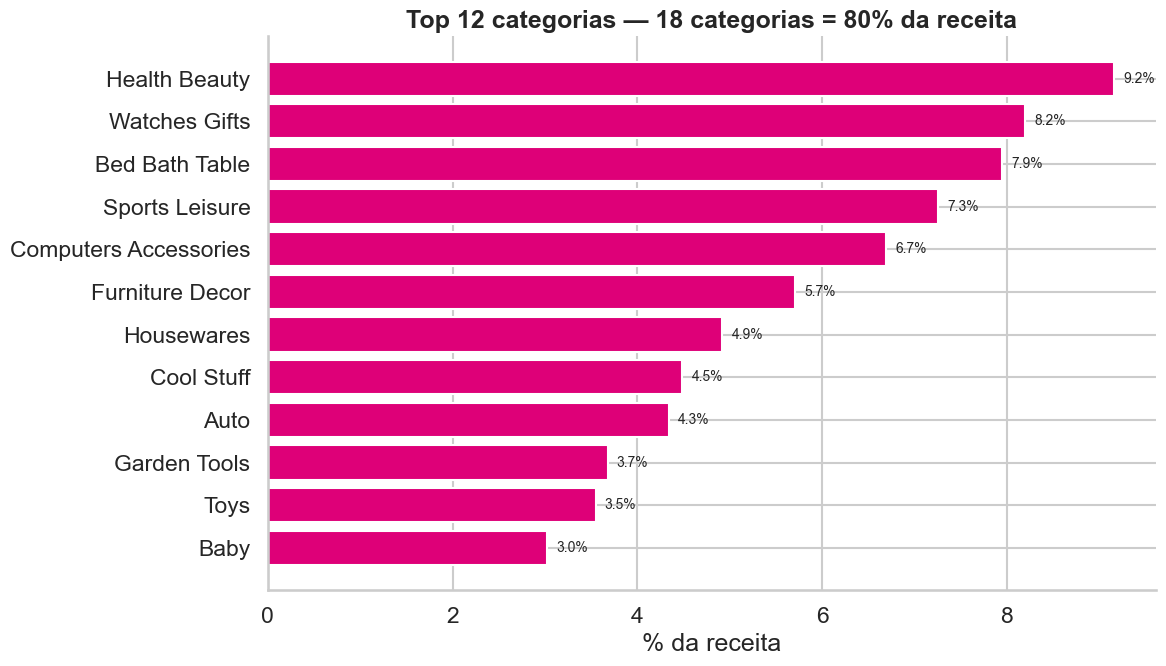

18 categorias concentram 80% da receita (cauda longa).


In [8]:
cat = (items_full.groupby("cat")
                 .agg(receita=("revenue","sum"), produto=("price","sum"),
                      pedidos=("order_id","nunique"))
                 .reset_index().sort_values("receita", ascending=False))
cat["share"] = cat["receita"]/cat["receita"].sum()
cat["ticket_cat"] = cat["produto"]/cat["pedidos"]
cat["cum"] = cat["share"].cumsum()
n80 = int((cat["cum"]<0.8).sum()+1)
top12 = cat.head(12)
fig, ax = plt.subplots(figsize=(12,7))
ax.barh(top12["cat"][::-1], (top12["share"]*100)[::-1], color=ROSA)
ax.set_xlabel("% da receita"); ax.set_title(f"Top 12 categorias — {n80} categorias = 80% da receita")
for i,v in enumerate((top12["share"]*100)[::-1]):
    ax.text(v+0.1, i, f"{v:.1f}%", va="center", fontsize=10)
plt.tight_layout(); plt.savefig(FIG_DIR/"geo_01_categorias.png"); plt.show()
print(f"{n80} categorias concentram 80% da receita (cauda longa).")

## 2. Q1 — Por que NE e Centro-Oeste compram menos que o Sul?

A resposta **não** é falta de demanda — é **falta de oferta local**. A oferta (sellers) está concentrada no
Sudeste; o NE tem só ~56 sellers e o CO ~79, contra **668 no Sul**. Quase tudo que NE/CO compram vem de longe,
o que dispara o frete — e o frete alto **filtra a compra**: só o pedido caro "compensa", então o volume de
compras pequenas do dia a dia (que sustenta o Sul) não acontece.

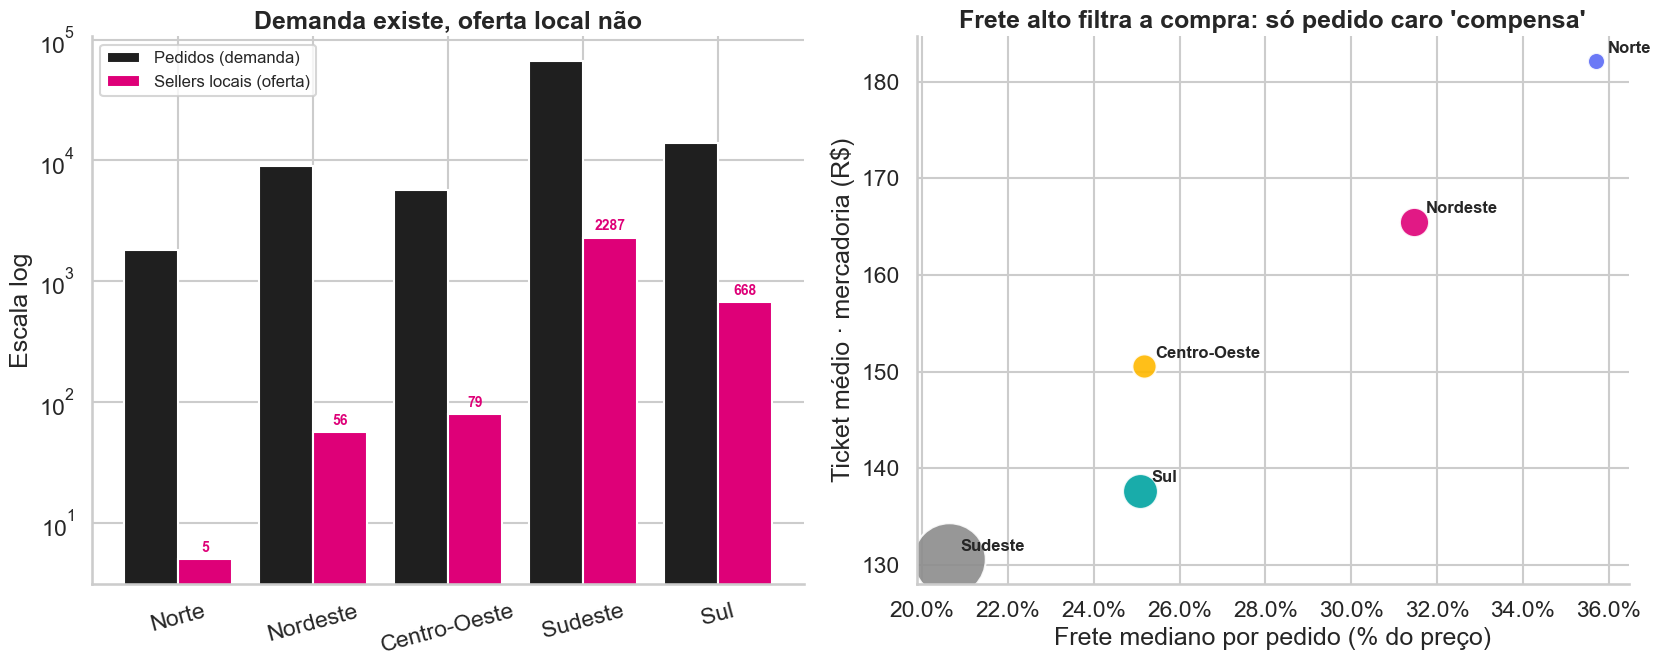

              pedidos  sellers  ticket_merc  frete_pct
regiao                                                
Norte            1796        5        182.1       35.7
Nordeste         9044       56        165.5       31.5
Centro-Oeste     5624       79        150.6       25.2
Sudeste         66200     2287        130.6       20.6
Sul             13814      668        137.7       25.1


In [9]:
import numpy as np
sellers_reg = sellers.assign(regiao=sellers["seller_state"].map(REGIAO)).groupby("regiao")["seller_id"].nunique()
g = reg.copy(); g["sellers"] = sellers_reg.reindex(ORDEM)

fig, ax = plt.subplots(1,2, figsize=(17,7))
x = np.arange(len(ORDEM))
ax[0].bar(x-0.2, g["pedidos"], 0.4, label="Pedidos (demanda)", color=PRETO)
ax[0].bar(x+0.2, g["sellers"], 0.4, label="Sellers locais (oferta)", color=ROSA)
ax[0].set_yscale("log"); ax[0].set_xticks(x); ax[0].set_xticklabels(ORDEM, rotation=15)
ax[0].set_ylabel("Escala log"); ax[0].set_title("Demanda existe, oferta local não")
ax[0].legend(fontsize=12)
for i,se in enumerate(g["sellers"]):
    ax[0].text(i+0.2, se*1.15, f"{int(se)}", ha="center", fontsize=10, color=ROSA, weight="bold")
for i,reg_ in enumerate(ORDEM):
    ax[1].scatter(g.loc[reg_,"frete_pct"], g.loc[reg_,"ticket_merc"], s=g.loc[reg_,"pedidos"]/25+80,
                  color=COR_REG[reg_], edgecolor="white", lw=1.5, alpha=.9)
    ax[1].annotate(reg_, (g.loc[reg_,"frete_pct"], g.loc[reg_,"ticket_merc"]),
                   textcoords="offset points", xytext=(8,6), fontsize=12, weight="bold")
ax[1].set_xlabel("Frete mediano por pedido (% do preço)"); ax[1].set_ylabel("Ticket médio · mercadoria (R$)")
ax[1].set_title("Frete alto filtra a compra: só pedido caro 'compensa'")
import matplotlib.ticker as mtick
ax[1].xaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout(); plt.savefig(FIG_DIR/"geo_q1_oferta_frete.png"); plt.show()
print(g[["pedidos","sellers","ticket_merc","frete_pct"]].round(1).to_string())

**Leitura da Q1:**
- **Oferta concentrada:** NE 56 e CO 79 sellers vs. **668 no Sul** e 2.287 no Sudeste. NE/CO importam ~95% do que consomem.
- **Frete como pedágio:** no pedido típico, o frete é ~**31% do preço no NE** e ~25% no CO (vs. 20% no Sudeste).
- **O efeito-filtro:** NE/CO têm o **maior ticket de mercadoria do país** (R$ 165 / R$ 150) — não por serem ricos,
  mas porque só vale a pena pagar o frete em pedidos caros. As compras pequenas, que dão volume ao Sul, evaporam.
- **Por isso o Sul compra mais:** tem oferta perto (668 sellers) e é colado no Sudeste → frete e prazo viáveis → o pedido pequeno acontece.

## 3. Categorias × região — o que destrava cada mercado

Onde o lado "Categorias" encontra o geográfico: as regiões têm **preferências distintas**. As categorias em
que NE/CO **sobre-indexam** (pesam mais do que pesariam na média nacional) são as candidatas naturais a
puxar a oferta local e os bundles regionais.

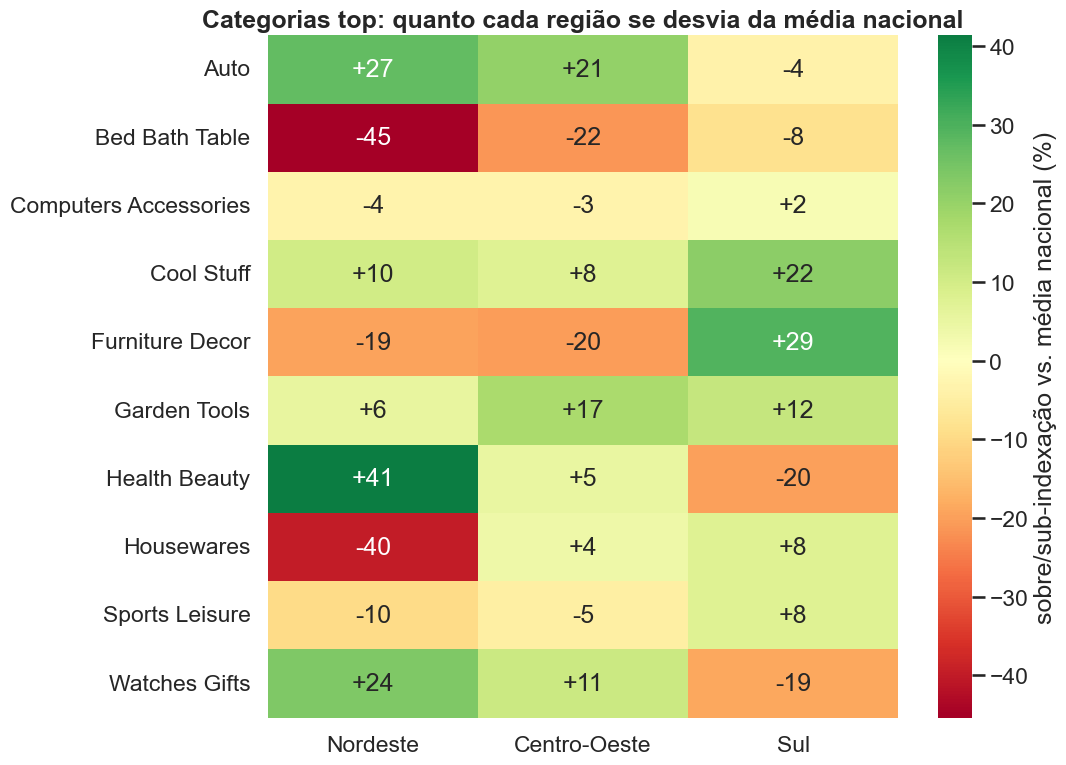

Categorias que MAIS sobre-indexam no Nordeste:
cat
Health Beauty    41.0
Auto             27.0
Watches Gifts    24.0
Cool Stuff       10.0


In [10]:
top_cats = cat.head(10)["cat"].tolist()
piv = (items_full[items_full["cat"].isin(top_cats)]
       .pivot_table(index="cat", columns="regiao", values="revenue", aggfunc="sum", fill_value=0))
share_reg = piv.div(piv.sum(axis=0), axis=1)          # peso da categoria dentro da regiao
share_nac = piv.sum(axis=1)/piv.sum().sum()            # peso nacional
overindex = share_reg.div(share_nac, axis=0)          # >1 = sobre-indexa
overindex = overindex[["Nordeste","Centro-Oeste","Sul"]]
fig, ax = plt.subplots(figsize=(11,8))
sns.heatmap((overindex-1)*100, annot=True, fmt="+.0f", center=0, cmap="RdYlGn",
            cbar_kws={"label":"sobre/sub-indexação vs. média nacional (%)"}, ax=ax)
ax.set_title("Categorias top: quanto cada região se desvia da média nacional")
ax.set_xlabel(""); ax.set_ylabel("")
plt.tight_layout(); plt.savefig(FIG_DIR/"geo_02_categoria_overindex.png"); plt.show()
print("Categorias que MAIS sobre-indexam no Nordeste:")
print((overindex["Nordeste"].sort_values(ascending=False).head(4)*100-100).round(0).to_string())

**Leitura:** as categorias em verde no NE/CO são as que esses mercados **já consomem acima da média** —
mesmo pagando frete alto. São a aposta mais segura para (a) recrutar sellers locais dessas categorias e
(b) montar bundles regionais. O sortimento amplo (seção 1) confirma que não basta levar 2-3 itens.

## 4. Q2 — O que melhorar para cumprir a promessa de entrega?

Decompondo o prazo em duas etapas — **(a) compra→postagem** (responsabilidade do *seller*) e
**(b) postagem→cliente** (responsabilidade do *transporte*) — fica claro onde o tempo é perdido.

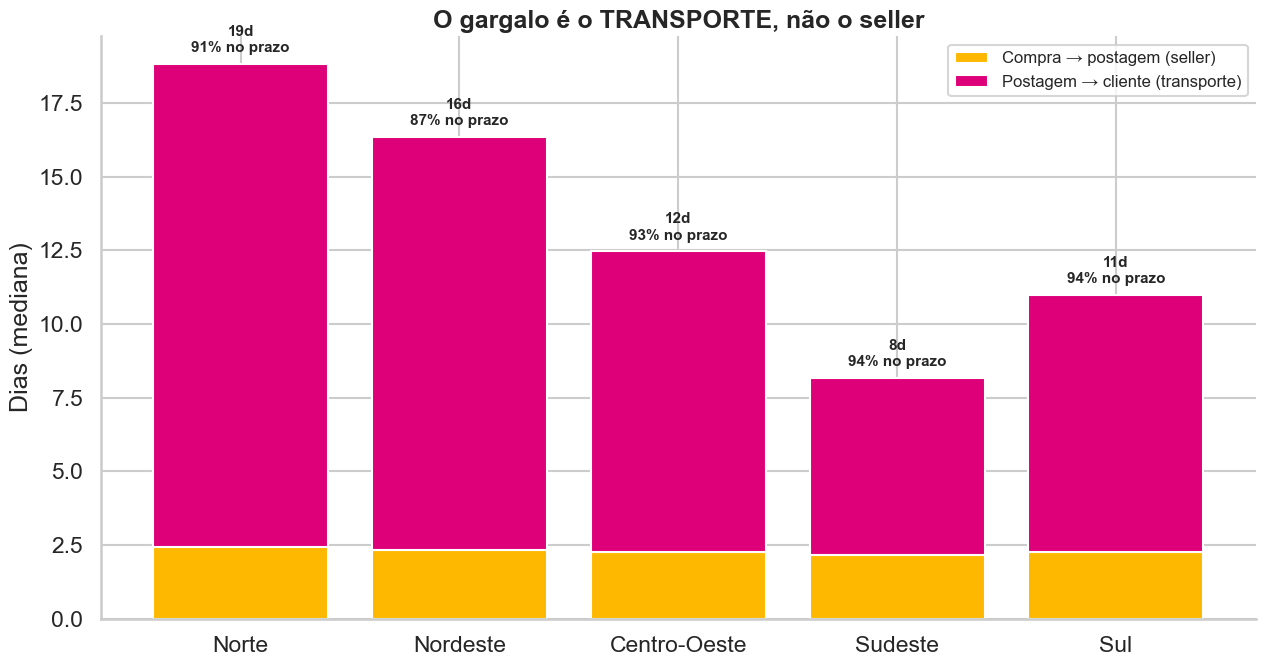

              t_postagem  t_transporte  no_prazo
regiao                                          
Norte                2.4          16.4      91.4
Nordeste             2.3          14.0      87.3
Centro-Oeste         2.3          10.2      93.5
Sudeste              2.2           6.0      93.9
Sul                  2.3           8.7      94.1


In [11]:
d = orders[orders["order_status"]=="delivered"].merge(
        customers[["customer_id","customer_state"]], on="customer_id", how="left")
d["regiao"] = d["customer_state"].map(REGIAO)
d["t_postagem"]   = (d["order_delivered_carrier_date"]-d["order_purchase_timestamp"]).dt.total_seconds()/86400
d["t_transporte"] = (d["order_delivered_customer_date"]-d["order_delivered_carrier_date"]).dt.total_seconds()/86400
d["t_total"]      = (d["order_delivered_customer_date"]-d["order_purchase_timestamp"]).dt.total_seconds()/86400
d["atraso"]       = (d["order_delivered_customer_date"]-d["order_estimated_delivery_date"]).dt.days
dd = d.dropna(subset=["t_postagem","t_transporte"])
q = dd.groupby("regiao").agg(t_postagem=("t_postagem","median"),
        t_transporte=("t_transporte","median"),
        no_prazo=("atraso", lambda x:(x<=0).mean()*100)).reindex(ORDEM)

fig, ax = plt.subplots(figsize=(13,7))
x = np.arange(len(ORDEM))
ax.bar(x, q["t_postagem"], color=AMARELO, label="Compra → postagem (seller)")
ax.bar(x, q["t_transporte"], bottom=q["t_postagem"], color=ROSA, label="Postagem → cliente (transporte)")
ax.set_xticks(x); ax.set_xticklabels(ORDEM); ax.set_ylabel("Dias (mediana)")
ax.set_title("O gargalo é o TRANSPORTE, não o seller")
for i,reg_ in enumerate(ORDEM):
    tot = q.loc[reg_,"t_postagem"]+q.loc[reg_,"t_transporte"]
    ax.text(i, tot+0.4, f"{tot:.0f}d\n{q.loc[reg_,'no_prazo']:.0f}% no prazo", ha="center", fontsize=11, weight="bold")
ax.legend(fontsize=12)
plt.tight_layout(); plt.savefig(FIG_DIR/"geo_q2_gargalo_entrega.png"); plt.show()
print(q.round(1).to_string())

**Leitura da Q2:**
- **O seller despacha rápido e por igual** em todo o Brasil (~2 dias). Pressionar SLA de seller **não move** NE/CO.
- **A diferença é 100% transporte:** 6 dias no Sudeste → **14 dias no Nordeste**. É a viagem de longa distância saindo do Sudeste.
- **NE tem o pior cumprimento de promessa (87%)** porque essa perna longa é também a mais **variável** — não dá para prometer com precisão.
- O próximo passo confirma a causa: **a origem do vendedor importa** (local × não-local) e, dentro do NE, **a distância** (mesmo estado × outro estado).

### 4a. Vendedor local entrega melhor — e onde mais importa, mais

Classificamos cada pedido entregue como **local** (todos os vendedores na mesma região do cliente) ou
**não-local**. Se a origem da oferta é a causa, o pedido local deve ser mais rápido e mais pontual.

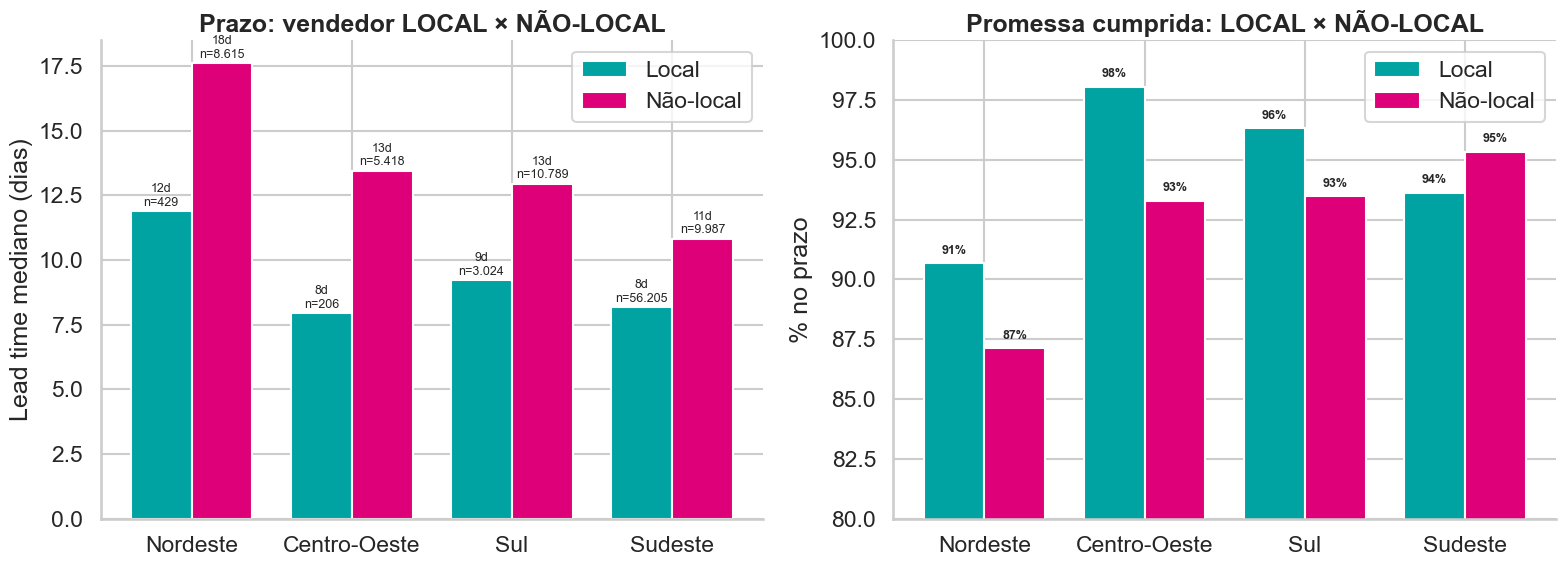

      regiao      tipo  pedidos  lead  no_prazo
Centro-Oeste     Local      206   8.0      98.1
Centro-Oeste Não-local     5418  13.5      93.3
    Nordeste     Local      429  11.9      90.7
    Nordeste Não-local     8615  17.6      87.1
     Sudeste     Local    56205   8.2      93.6
     Sudeste Não-local     9987  10.8      95.3
         Sul     Local     3024   9.2      96.3
         Sul Não-local    10789  13.0      93.5


In [12]:
it_sel = items.merge(sellers[["seller_id","seller_state"]], on="seller_id", how="left")
it_sel["sreg"] = it_sel["seller_state"].map(REGIAO)
oc = (dd[["order_id","regiao","customer_state","atraso"]]
      .merge(it_sel[["order_id","seller_state","sreg"]], on="order_id", how="inner")
      .dropna(subset=["regiao","sreg"]))
def _cls(x):
    return pd.Series({"local_reg":(x["sreg"]==x["regiao"].iloc[0]).all(),
                      "same_state":(x["seller_state"]==x["customer_state"].iloc[0]).all()})
flags = oc.groupby("order_id").apply(_cls, include_groups=False).reset_index()
dq = dd.merge(flags, on="order_id", how="inner")
dq["lead"] = dq["t_total"]; dq["tipo"] = np.where(dq["local_reg"],"Local","Não-local")

ORD4 = ["Nordeste","Centro-Oeste","Sul","Sudeste"]
agg = (dq[dq["regiao"].isin(ORD4)].groupby(["regiao","tipo"])
       .agg(pedidos=("order_id","size"), lead=("lead","median"),
            no_prazo=("atraso", lambda x:(x<=0).mean()*100)).reset_index())
fig, ax = plt.subplots(1,2, figsize=(16,6)); x = np.arange(len(ORD4)); w=0.38
for j,(tp,cor) in enumerate([("Local",TEAL),("Não-local",ROSA)]):
    sub = agg[agg["tipo"]==tp].set_index("regiao").reindex(ORD4)
    ax[0].bar(x+(j-0.5)*w, sub["lead"], w, label=tp, color=cor)
    for i,(v,n) in enumerate(zip(sub["lead"],sub["pedidos"])):
        if pd.notna(v): ax[0].text(x[i]+(j-0.5)*w, v+0.2, f"{v:.0f}d\nn={int(n):,}".replace(",","."), ha="center", fontsize=9)
    ax[1].bar(x+(j-0.5)*w, sub["no_prazo"], w, label=tp, color=cor)
    for i,v in enumerate(sub["no_prazo"]):
        if pd.notna(v): ax[1].text(x[i]+(j-0.5)*w, v+0.4, f"{v:.0f}%", ha="center", fontsize=9, weight="bold")
ax[0].set_xticks(x); ax[0].set_xticklabels(ORD4); ax[0].set_ylabel("Lead time mediano (dias)")
ax[0].set_title("Prazo: vendedor LOCAL × NÃO-LOCAL"); ax[0].legend()
ax[1].set_xticks(x); ax[1].set_xticklabels(ORD4); ax[1].set_ylabel("% no prazo"); ax[1].set_ylim(80,100)
ax[1].set_title("Promessa cumprida: LOCAL × NÃO-LOCAL"); ax[1].legend()
plt.tight_layout(); plt.savefig(FIG_DIR/"geo_q2_local_vs_naolocal.png"); plt.show()
print(agg.round(1).to_string(index=False))

**Vendedor local entrega ~5 dias mais rápido** (8 vs 13 dias no agregado), e o ganho é maior justamente nas
regiões foco: no **Nordeste**, local 11d/91% vs não-local 17d/87%; no **Centro-Oeste**, local 7d/98% vs
não-local 13d/93%. **Onde já existe oferta local, a entrega já é rápida e cumpre a promessa** — é a prova
empírica de que aproximar a oferta resolve o Q2.

### 4b. Por que o NE demora mesmo *local*? Distância — não o vendedor

O pedido "local" do NE ainda leva ~12 dias, bem mais que o do CO (8d). O motivo: **"local" aqui é *mesma
região*, e o Nordeste é enorme** (9 estados). Abrimos o NE em (i) etapas e (ii) mesmo-estado × outro-estado.

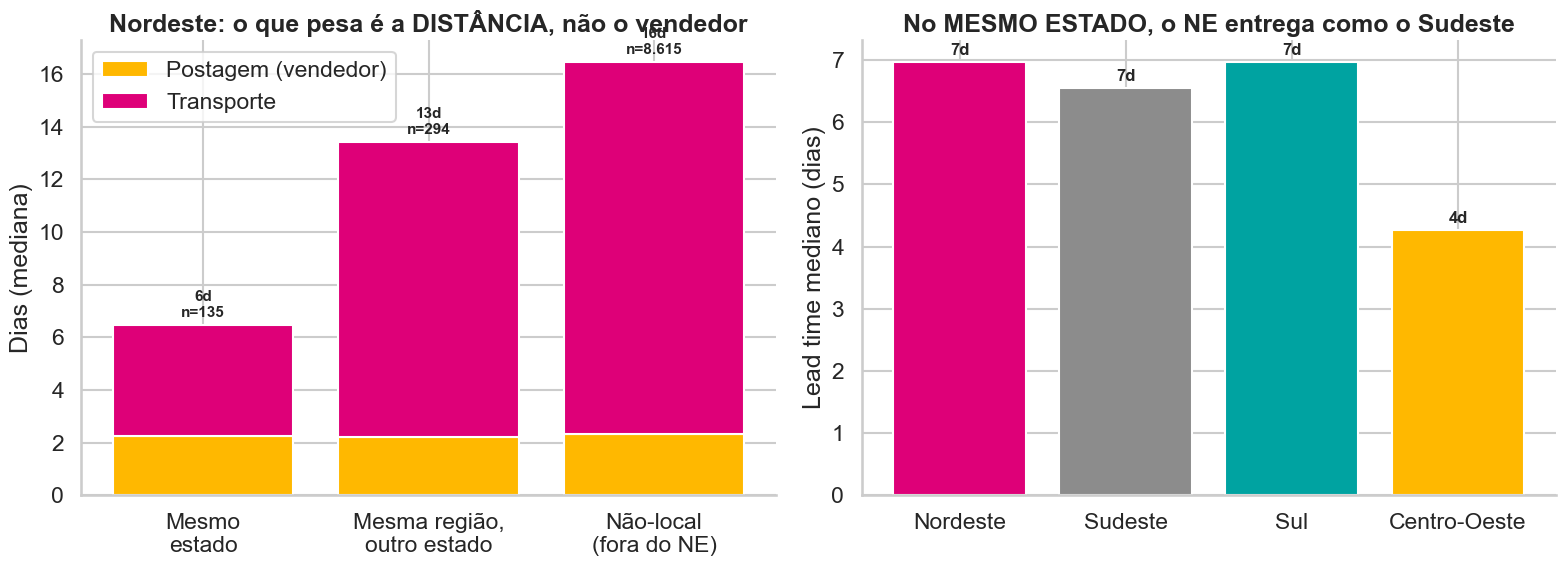

NE mesmo-estado: lead 7.0 | outro estado: 13.5


In [13]:
ne = dq[dq["regiao"]=="Nordeste"].dropna(subset=["t_postagem","t_transporte","lead"]).copy()
grp = {"Mesmo\nestado": ne[ne["same_state"]],
       "Mesma região,\noutro estado": ne[ne["local_reg"] & ~ne["same_state"]],
       "Não-local\n(fora do NE)": ne[~ne["local_reg"]]}
post = [x["t_postagem"].median() for x in grp.values()]
trans= [x["t_transporte"].median() for x in grp.values()]
ns   = [len(x) for x in grp.values()]
fig, ax = plt.subplots(1,2, figsize=(16,6)); xs = np.arange(len(grp))
ax[0].bar(xs, post, color=AMARELO, label="Postagem (vendedor)")
ax[0].bar(xs, trans, bottom=post, color=ROSA, label="Transporte")
for i in range(len(grp)):
    ax[0].text(i, post[i]+trans[i]+0.3, f"{post[i]+trans[i]:.0f}d\nn={ns[i]:,}".replace(",","."), ha="center", fontsize=11, weight="bold")
ax[0].set_xticks(xs); ax[0].set_xticklabels(grp.keys()); ax[0].set_ylabel("Dias (mediana)")
ax[0].set_title("Nordeste: o que pesa é a DISTÂNCIA, não o vendedor"); ax[0].legend()
rgs = ["Nordeste","Sudeste","Sul","Centro-Oeste"]; corr={"Nordeste":ROSA,"Sudeste":CINZA,"Sul":TEAL,"Centro-Oeste":AMARELO}
ss = [dq[(dq["regiao"]==r) & dq["same_state"]]["lead"].median() for r in rgs]
ax[1].bar(rgs, ss, color=[corr[r] for r in rgs])
for i,v in enumerate(ss): ax[1].text(i, v+0.12, f"{v:.0f}d", ha="center", fontsize=12, weight="bold")
ax[1].set_ylabel("Lead time mediano (dias)"); ax[1].set_title("No MESMO ESTADO, o NE entrega como o Sudeste")
plt.tight_layout(); plt.savefig(FIG_DIR/"geo_q2_distancia_ne.png"); plt.show()
print("NE mesmo-estado: lead", round(ne[ne["same_state"]]["lead"].median(),1),
      "| outro estado:", round(ne[ne["local_reg"]&~ne["same_state"]]["lead"].median(),1))

**A resposta:** o NE demora mesmo "local" por **distância**, não por vendedor. A postagem fica constante (~2
dias) em todos os recortes; o que cresce é o **transporte**. Dos pedidos locais do NE, a maioria **cruza estados
dentro do NE** (ex.: BA→MA, ~13 dias). Quando vendedor e cliente estão no **mesmo estado**, o NE entrega em
**7 dias — igual ao Sudeste (6,5d)**. Não há nada de intrinsecamente lento no Nordeste.

> **Isto refina a recomendação:** não basta "um hub no Nordeste" — cruzar estados dentro do NE já custa ~6 dias.
> O alvo é **fulfillment distribuído nos estados-âncora de demanda (BA, PE, CE)**, maximizando a fatia de pedidos
> *same-state* (que já entrega em 7 dias). _(Ressalva: o n de same-state no NE é pequeno — 135 — porque hoje quase
> não há vendedor local; o mecanismo de distância, porém, é inequívoco.)_

## 5. Por que isso importa: a satisfação segue a promessa de entrega

O elo final: cumprir a promessa **é** o que sustenta a nota. A baseline de satisfação por região define a
linha de partida — e mostra que o **Nordeste é a maior alavanca** (menor nota, mais detratores).

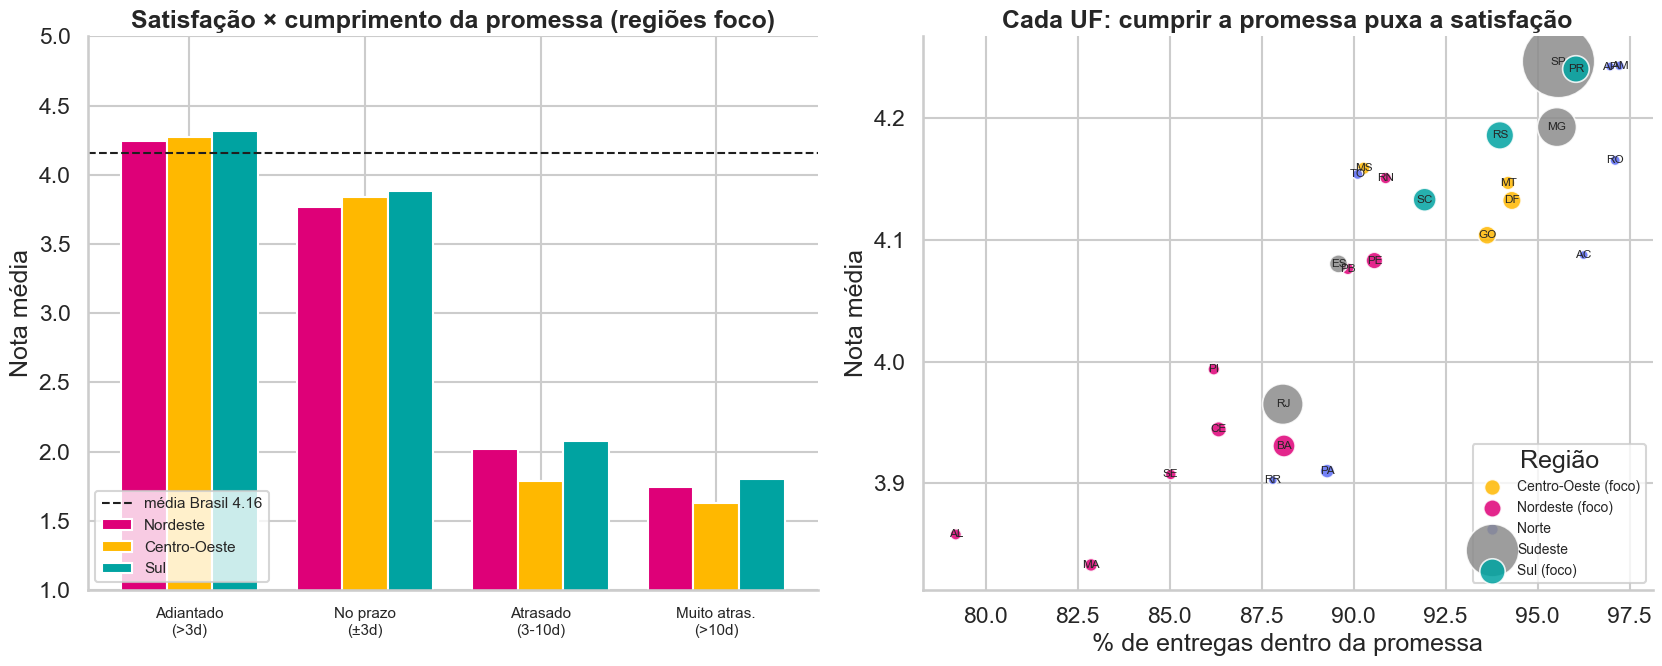

              nota_media  pct_no_prazo  pct_detratores
regiao                                                
Norte               4.03         91.68           15.23
Nordeste            3.97         87.51           16.74
Centro-Oeste        4.13         93.55           13.17
Sudeste             4.18         93.99           12.37
Sul                 4.19         94.19           11.82


In [14]:
rv = reviews[["order_id","review_score"]].drop_duplicates("order_id")
dr = dd.merge(rv, on="order_id", how="inner").dropna(subset=["review_score"])
dr["no_prazo"] = dr["atraso"]<=0
faixas = ["Adiantado\n(>3d)","No prazo\n(±3d)","Atrasado\n(3-10d)","Muito atras.\n(>10d)"]
def fa(a): return faixas[0] if a<-3 else faixas[1] if a<=3 else faixas[2] if a<=10 else faixas[3]
dr["faixa"] = dr["atraso"].apply(fa)
piv2 = dr[dr["regiao"].isin(FOCO)].groupby(["faixa","regiao"])["review_score"].mean().unstack().reindex(faixas)

fig, ax = plt.subplots(1,2, figsize=(17,7))
xx = np.arange(len(faixas)); w=0.26
for i,r_ in enumerate(FOCO):
    ax[0].bar(xx+(i-1)*w, piv2[r_].values, w, label=r_, color=COR_REG[r_])
ax[0].axhline(dr["review_score"].mean(), color=PRETO, ls="--", lw=1.5, label=f"média Brasil {dr['review_score'].mean():.2f}")
ax[0].set_xticks(xx); ax[0].set_xticklabels(faixas, fontsize=11); ax[0].set_ylim(1,5)
ax[0].set_ylabel("Nota média"); ax[0].set_title("Satisfação × cumprimento da promessa (regiões foco)")
ax[0].legend(fontsize=11, loc="lower left")
ufq = dr.groupby("customer_state").agg(nota=("review_score","mean"), no_prazo=("no_prazo","mean"),
        pedidos=("order_id","count")).reset_index()
ufq["regiao"] = ufq["customer_state"].map(REGIAO)
for r_, sub in ufq.groupby("regiao"):
    ax[1].scatter(sub["no_prazo"]*100, sub["nota"], s=sub["pedidos"]/15+40, color=COR_REG[r_],
                  alpha=.85, edgecolor="white", lw=1.2, label=r_+(" (foco)" if r_ in FOCO else ""))
for _,r2 in ufq.iterrows():
    ax[1].annotate(r2["customer_state"], (r2["no_prazo"]*100, r2["nota"]), fontsize=8.5, ha="center", va="center")
ax[1].set_xlabel("% de entregas dentro da promessa"); ax[1].set_ylabel("Nota média")
ax[1].set_title("Cada UF: cumprir a promessa puxa a satisfação"); ax[1].legend(fontsize=10, loc="lower right", title="Região")
plt.tight_layout(); plt.savefig(FIG_DIR/"geo_satisfacao_promessa.png"); plt.show()

base = (dr.groupby("regiao").agg(nota_media=("review_score","mean"),
        pct_no_prazo=("no_prazo",lambda s:s.mean()*100),
        pct_detratores=("review_score",lambda s:(s<=2).mean()*100)).reindex(ORDEM).round(2))
print(base.to_string())

### 5a. O atraso *causa* a queda de nota? Teste estatístico (Welch t-test)

Para não depender só da diferença visual de médias, aplicamos um **Welch t-test** (robusto a variâncias e
tamanhos de amostra desiguais) comparando a nota de pedidos **no prazo** vs. **atrasados** — nacional e nas
regiões foco. Se a diferença for significativa (p baixo), o atraso é um detrator real, não ruído amostral.

In [15]:
from scipy.stats import ttest_ind
def welch(df):
    a = df[df["no_prazo"]]["review_score"].dropna()
    b = df[~df["no_prazo"]]["review_score"].dropna()
    t, p = ttest_ind(a, b, equal_var=False)
    return a.mean(), b.mean(), a.mean()-b.mean(), p, len(a), len(b)
linhas = []
for nome, df in [("Nacional", dr), ("Nordeste", dr[dr.regiao=="Nordeste"]), ("Centro-Oeste", dr[dr.regiao=="Centro-Oeste"])]:
    op, at, dif, p, na, nb = welch(df)
    linhas.append({"recorte":nome, "nota_no_prazo":round(op,2), "nota_atraso":round(at,2),
                   "queda":round(dif,2), "p_valor":f"{p:.1e}", "n":na+nb})
welch_df = pd.DataFrame(linhas)
welch_df.to_csv(OUT_DIR/"geo_welch_ttest.csv", index=False)
print(welch_df.to_string(index=False))

     recorte  nota_no_prazo  nota_atraso  queda  p_valor     n
    Nacional           4.29         2.27   2.02  0.0e+00 95823
    Nordeste           4.23         2.18   2.04 1.7e-251  8975
Centro-Oeste           4.26         2.18   2.08  9.2e-86  5594


**Resultado:** a queda é de **~2 estrelas** em todos os recortes, com **p-valor praticamente zero**
(nacional p≈0; NE p≈1,7e-251; CO p≈9e-86). A diferença é **estatisticamente significante** — o atraso é,
comprovadamente, o maior detrator individual da experiência. Não é coincidência amostral.

## 6. Síntese — uma causa raiz, dois sintomas

As duas perguntas têm a **mesma origem: a oferta concentrada no Sudeste.**

| | Q1 — compram menos | Q2 — entrega atrasa |
|---|---|---|
| **Sintoma** | volume baixo no NE/CO | promessa furada, nota baixa (NE 3,97) |
| **Mecanismo** | sem seller local → frete alto → filtra a compra pequena | sem origem local → perna de transporte longa e variável |
| **Causa raiz comum** | **oferta (sellers/estoque) longe do cliente** | **oferta (sellers/estoque) longe do cliente** |

> Colocar oferta **dentro** do NE/CO ataca os dois ao mesmo tempo: baixa o frete (mais compras) **e** encurta
> o transporte (cumpre a promessa). É **uma alavanca, dois problemas resolvidos**.

## 7. Recomendações geográficas — com metas de satisfação

Foco em NE e CO (Norte = restrição geográfica reconhecida; Sul = manter). Métrica-norte: **satisfação média regional.**

| # | Ação | Resolve | Meta (linha de partida → alvo) | Prazo |
|---|---|---|---|---|
| 1 | **Fulfillment distribuído nos estados-âncora (BA, PE, CE)** — não um hub único | Q1 (frete) + Q2 (transporte) | NE: nota 3,97 → **4,15** · no prazo 87% → **93%** · ↑ fatia *same-state* | 90–180d |
| 2 | **Recrutar sellers locais NE/CO** nas categorias que sobre-indexam | Q1 (oferta/frete) | NE sellers 56 → **150+**, espalhados por estado | 6–12m |
| 3 | **Transportadora regional dedicada** no corredor Sudeste→NE/CO **e intra-NE** | Q2 (transporte, inclusive cruzando estados do NE) | reduzir variância; CO 93,5% → **95%** | 90d |
| 4 | **Bundles regionais** nas categorias de sobre-indexação | Q1 (ticket/volume) | itens/pedido e volume NE/CO ↑ | 30–60d |
| 5 | **Recalibrar a data prometida por rota** enquanto a oferta local não cresce | Q2 (promessa) | quebra de promessa NE ↓ | 30d (tático) |

> **Não fazer:** (a) apostar num **hub único no Nordeste** — cruzar estados dentro do NE ainda custa ~6 dias;
> o alvo é distribuir perto da demanda (same-state entrega em 7d). (b) Prometer prazos agressivos no NE antes de
> ter oferta local. (c) Tratar o Norte como NE — lá a barreira é geográfica (rios/estradas), fora do alcance da
> empresa. (d) Pressionar SLA de seller esperando ganho de prazo — o vendedor posta em 2 dias, não é o gargalo.

### Mensagem ao board
> O mapa de receita da Olist não é destino, é **consequência da localização da oferta**. NE e CO compram pouco
> e recebem atrasado pela **mesma razão** — não há vendedor por perto. A prova: onde o vendedor é **do mesmo
> estado**, o NE entrega em 7 dias, igual ao Sudeste. Aproximar a oferta — **distribuída nos estados de maior
> demanda**, não num hub único — converte a demanda premium já existente **e** cumpre a promessa de entrega,
> medido pela **satisfação** dessas regiões.

## 8. Quanto isso vale: simulação do cenário de descentralização (30%)

Para dimensionar o retorno, modelamos um cenário em que **30% dos pedidos hoje despachados de fora da região
migram para sourcing local** (seller local ou estoque avançado). Aplicamos aos pedidos migrados o desempenho
já observado nos pedidos locais — frete, taxa de atraso e nota. É um cenário-base, não previsão de precisão.

In [16]:
sim_rows = []
dq_sim = dq.merge(orders_v[["order_id","freight"]], on="order_id", how="left")
for rg in ["Nordeste","Centro-Oeste"]:
    sub = dq_sim[dq_sim["regiao"]==rg]
    nl = sub[sub["local_reg"]==False]; lo = sub[sub["local_reg"]==True]
    n = len(nl); shift = int(round(0.30*n))
    avoided = shift*((nl["atraso"]>0).mean() - (lo["atraso"]>0).mean())
    save = shift*(nl["freight"].mean() - lo["freight"].mean())
    sim_rows.append({"Região":rg, "Pedidos migrados (30%)":shift,
                     "Atrasos evitados":int(round(avoided)),
                     "Economia de frete (R$)":round(save,0)})
sim = pd.DataFrame(sim_rows)
tot = {"Região":"TOTAL", "Pedidos migrados (30%)":sim["Pedidos migrados (30%)"].sum(),
       "Atrasos evitados":sim["Atrasos evitados"].sum(),
       "Economia de frete (R$)":sim["Economia de frete (R$)"].sum()}
sim = pd.concat([sim, pd.DataFrame([tot])], ignore_index=True)
sim.to_csv(OUT_DIR/"geo_simulacao_30pct.csv", index=False)
print(sim.to_string(index=False))

      Região  Pedidos migrados (30%)  Atrasos evitados  Economia de frete (R$)
    Nordeste                    2584                92                 35812.0
Centro-Oeste                    1625                77                 15429.0
       TOTAL                    4209               169                 51241.0


**Resultado do cenário:** migrar 30% dos envios de fora da região rende, por ano-base do dataset,
**~169 atrasos evitados** e **~R$ 51 mil de economia de frete** no NE + CO — capital que financia a própria
atração de sellers locais (recomendação #2). Além disso, os pedidos migrados ganham ~**+0,3 estrela** de nota
média (passam do desempenho "não-local" para o "local"), elevando satisfação e, por consequência, a recompra.

> Modelo transparente e conservador: assume que o pedido migrado herda exatamente o desempenho local atual.
> Números próprios (podem diferir de outras simulações conforme as premissas de frete e base de migração).

In [17]:
reg.to_csv(OUT_DIR/"geo_panorama_regiao.csv")
g[["pedidos","sellers","ticket_merc","frete_pct"]].to_csv(OUT_DIR/"geo_diagnostico_regiao.csv")
q.to_csv(OUT_DIR/"geo_decomposicao_leadtime.csv")
base.to_csv(OUT_DIR/"baseline_satisfacao_regiao.csv")
overindex.to_csv(OUT_DIR/"geo_categoria_overindex.csv")
cat.head(15).to_csv(OUT_DIR/"geo_top15_categorias.csv", index=False)
print("Exports geográficos salvos.")

Exports geográficos salvos.
